## Lanchain communication chain

In [1]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

messages = [AIMessage(content=f"so you said we were researching ocean mamals?", name="Model")]
messages.extend([HumanMessage(content=f"Yes, that's right.", name="Harry")])
messages.extend([AIMessage(content=f"Great, What would you like to learn about", name="Model")])
messages.extend([HumanMessage(content="I want to learn about the best place to see Orcas in the US.",name="Harry")])

for msg in messages:
    msg.pretty_print()

================================== Ai Message ==================================
Name: Model

so you said we were researching ocean mamals?
================================ Human Message =================================
Name: Harry

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, What would you like to learn about
================================ Human Message =================================
Name: Harry

I want to learn about the best place to see Orcas in the US.


## Chat Models

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")
        
_set_env("OPENAI_API_KEY")

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [4]:
result

AIMessage(content="If you're interested in seeing orcas in the United States, one of the best places to visit is the Pacific Northwest, particularly around the San Juan Islands in Washington State. The waters around these islands are home to several pods of resident orcas, making it one of the most reliable and accessible locations to observe these majestic creatures.\n\nHere are some tips for seeing orcas in this area:\n\n1. **San Juan Islands**: The town of Friday Harbor on San Juan Island is a popular starting point for orca-watching tours. Several companies offer boat tours that take you into prime orca-watching waters.\n\n2. **Lime Kiln Point State Park**: Also known as “Whale Watch Park,” this is one of the best spots in the world to see orcas from land. The park is located on the west side of San Juan Island.\n\n3. **Best Time to Visit**: The peak season for orca sightings in the San Juan Islands is from late spring to early fall, with the best time typically being between May a

In [5]:
result.response_metadata

{'token_usage': {'completion_tokens': 384,
  'prompt_tokens': 67,
  'total_tokens': 451,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_provider': 'openai',
 'model_name': 'gpt-4o-2024-08-06',
 'system_fingerprint': 'fp_246dab3317',
 'id': 'chatcmpl-Dk45qq81KD5PS89I1JH25Aawejkbf',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

In [6]:
# you can pass python function into ChatModel.bind_tools()

def multiply(a: int, b: int) -> int:
    """Multiply a and b
    Args:
        a: first int
        b: second int
    """
    return a*b

llm_with_tools = llm.bind_tools([multiply])

In [7]:
tool_call = llm_with_tools.invoke([HumanMessage(content="What is 2 multiplied by 3", name="Harry")])
tool_call

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 69, 'total_tokens': 86, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_310038b1e7', 'id': 'chatcmpl-Dk45yAhjxDHtxx64ioEbhcL2Zx7BM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e6897-3737-72b1-9502-cccabcb20167-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_a4CCO5rPZAZBJpHQxNTA72Yx', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 69, 'output_tokens': 17, 'total_tokens': 86, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [8]:
tool_call.model_dump()

{'content': '',
 'additional_kwargs': {'refusal': None},
 'response_metadata': {'token_usage': {'completion_tokens': 17,
   'prompt_tokens': 69,
   'total_tokens': 86,
   'completion_tokens_details': {'accepted_prediction_tokens': 0,
    'audio_tokens': 0,
    'reasoning_tokens': 0,
    'rejected_prediction_tokens': 0},
   'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
  'model_provider': 'openai',
  'model_name': 'gpt-4o-2024-08-06',
  'system_fingerprint': 'fp_310038b1e7',
  'id': 'chatcmpl-Dk45yAhjxDHtxx64ioEbhcL2Zx7BM',
  'service_tier': 'default',
  'finish_reason': 'tool_calls',
  'logprobs': None},
 'type': 'ai',
 'name': None,
 'id': 'lc_run--019e6897-3737-72b1-9502-cccabcb20167-0',
 'tool_calls': [{'name': 'multiply',
   'args': {'a': 2, 'b': 3},
   'id': 'call_a4CCO5rPZAZBJpHQxNTA72Yx',
   'type': 'tool_call'}],
 'invalid_tool_calls': [],
 'usage_metadata': {'input_tokens': 69,
  'output_tokens': 17,
  'total_tokens': 86,
  'input_token_details': {'audio':

In [9]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_a4CCO5rPZAZBJpHQxNTA72Yx',
  'type': 'tool_call'}]

## Using Messages as state

In [11]:
from typing import TypedDict
from langchain_core.messages import AnyMessage

class MessageState(TypedDict):
    messages: list[AnyMessage]

## Reducers

Now, we have a minor problem!

each node will return a new value for our state key messages.

But, this new value will overwrite the prior messages value!

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

Reducers specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [14]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built MessagesState!

MessagesState is defined:

With a pre-build single messages key
This is a list of AnyMessage objects
It uses the add_messages reducer
We'll usually use MessagesState because it is less verbose than defining a custom TypedDict, as shown above.

In [12]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

In [15]:
# To go a bit deeper, we can see how the add_messages reducer works in isolation.

# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you today?", name="Model"),
                    HumanMessage(content="I'm looking information on marine biology.", name="Harry")
                    ] 

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages, new_message)

[AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, name='Model', id='d1ebfbcc-04db-4a64-96b0-a0215ad7a39d', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking information on marine biology.", additional_kwargs={}, response_metadata={}, name='Harry', id='ec88e462-691a-40e8-b105-405c2369017d'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='446a235f-7c9c-489a-8b45-ad3d87b76bdc', tool_calls=[], invalid_tool_calls=[])]

## Our Graph

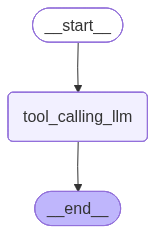

In [16]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hi there! How can I assist you today?


In [18]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_ROvGUGVpsbfjGwPPXK3UC8h6)
 Call ID: call_ROvGUGVpsbfjGwPPXK3UC8h6
  Args:
    a: 2
    b: 3


In [27]:
messages['messages'][1].tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_ROvGUGVpsbfjGwPPXK3UC8h6',
  'type': 'tool_call'}]

In [28]:
messages

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='9744a991-1dfd-4509-b72a-ddf5d18e934b'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 65, 'total_tokens': 82, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_310038b1e7', 'id': 'chatcmpl-Dk4ItVEnFxMKaIDUu7zo9X7btHuub', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e68a3-6f8f-7b01-adf4-5d16d401162d-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_ROvGUGVpsbfjGwPPXK3UC8h6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 65, 'output_tokens': 17, 'total_t